## **Import Libraries**

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

## **Load Dataset**

In [7]:
df = pd.read_csv(r"C:\Users\afzal\Desktop\ML FIles\loan_prediction.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## **Basic Information**

In [9]:
print(df.shape)
df.describe()
df.info()

(614, 13)
<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 67.2+ KB


## **Missing Values**

In [10]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

## Visualize

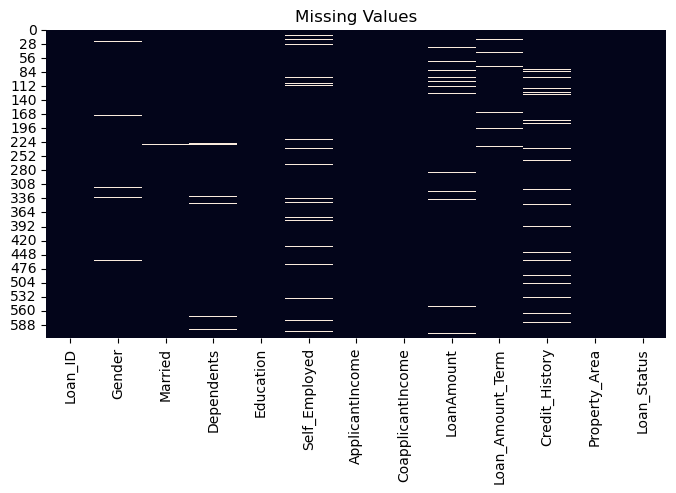

In [12]:
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(),cbar=False)
plt.title("Missing Values")
plt.show()

## **Target Distribution**

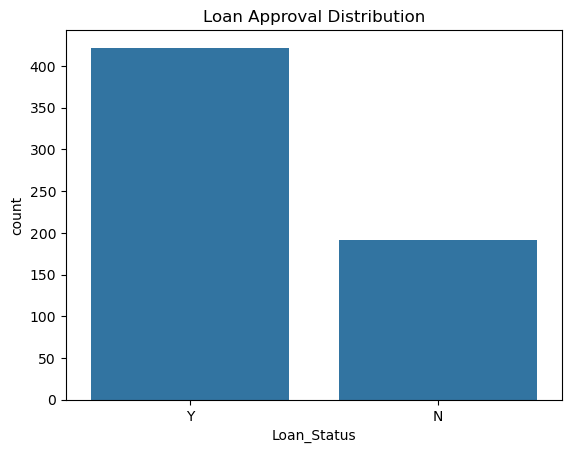

Class imbalance exists because approved loans are much more than rejected loans.


In [14]:
sns.countplot(x='Loan_Status',data=df)
plt.title("Loan Approval Distribution")
plt.show()
print("Class imbalance exists because approved loans are much more than rejected loans.")

## **Missing Value Treatment**

## Numerical Columns

In [16]:
num_cols = ['LoanAmount','Loan_Amount_Term']
for col in num_cols:
    df[col].fillna(df[col].median(),inplace=True)

## Categorical Columns

In [17]:
cat_cols = [
    'Gender',
    'Married',
    'Dependents',
    'Self_Employed',
    'Credit_History']
for col in cat_cols:
    df[col].fillna(
        df[col].mode()[0],
        inplace=True
    )

## **Feature Engineering**

In [19]:
df["TotalIncome"] = (
    df["ApplicantIncome"] +
    df["CoapplicantIncome"]
)

In [20]:
df["ApplicantIncome_Log"] = np.log1p(
    df["ApplicantIncome"]
)

df["LoanAmount_Log"] = np.log1p(
    df["LoanAmount"]
)

## **Encode Categorical Variables**

## Drop Loan ID

In [21]:
df.drop(
    "Loan_ID",
    axis=1,
    inplace=True
)

In [22]:
encoder = LabelEncoder()

for col in df.select_dtypes(include="object"):
    df[col] = encoder.fit_transform(df[col])

In [23]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,ApplicantIncome_Log,LoanAmount_Log
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1,5849.0,8.674197,4.859812
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0,6091.0,8.430327,4.859812
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1,3000.0,8.006701,4.204693
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1,4941.0,7.857094,4.795791
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1,6000.0,8.699681,4.955827


## **Correlation Heatmap**

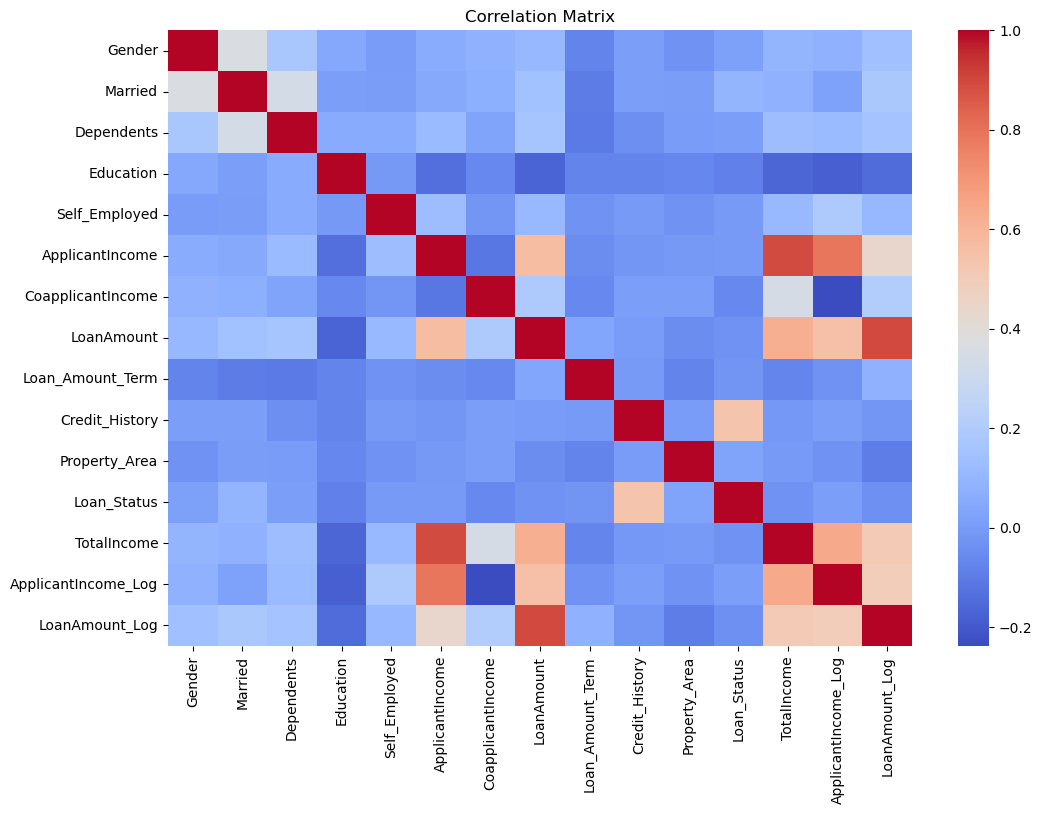

In [24]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)
plt.title("Correlation Matrix")
plt.show()

## **Feature Target Split**

In [25]:
X = df.drop(
    "Loan_Status",
    axis=1
)

y = df["Loan_Status"]

## **Train Test Split**

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## **Scaling**

In [27]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## **Handle Imbalance Using SMOTE**

## Before

In [28]:
print(y_train.value_counts())

Loan_Status
1    337
0    154
Name: count, dtype: int64


## Apply SMOTE:

In [29]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

## After:

In [30]:
print(y_train_smote.value_counts())

Loan_Status
1    337
0    337
Name: count, dtype: int64


## **Logistic Regression**

In [31]:
lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

lr.fit(
    X_train_smote,
    y_train_smote
)

lr_pred = lr.predict(
    X_test_scaled
)

lr_prob = lr.predict_proba(
    X_test_scaled
)[:,1]

## **Random Forest** 

In [32]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf.fit(
    X_train_smote,
    y_train_smote
)

rf_pred = rf.predict(
    X_test_scaled
)

rf_prob = rf.predict_proba(
    X_test_scaled
)[:,1]

## **Evaluation Function**

In [33]:
def evaluate_model(
    y_true,
    y_pred,
    y_prob,
    model_name
):

    print(model_name)

    print(
        "Precision:",
        precision_score(
            y_true,
            y_pred
        )
    )

    print(
        "Recall:",
        recall_score(
            y_true,
            y_pred
        )
    )

    print(
        "F1:",
        f1_score(
            y_true,
            y_pred
        )
    )

    print(
        "ROC-AUC:",
        roc_auc_score(
            y_true,
            y_prob
        )
    )

    print()

## **Compare Models**

In [34]:
evaluate_model(
    y_test,
    lr_pred,
    lr_prob,
    "Logistic Regression"
)

evaluate_model(
    y_test,
    rf_pred,
    rf_prob,
    "Random Forest"
)

Logistic Regression
Precision: 0.8735632183908046
Recall: 0.8941176470588236
F1: 0.8837209302325582
ROC-AUC: 0.7931888544891641

Random Forest
Precision: 0.8505747126436781
Recall: 0.8705882352941177
F1: 0.8604651162790697
ROC-AUC: 0.818266253869969



## **Confusion Matrix**

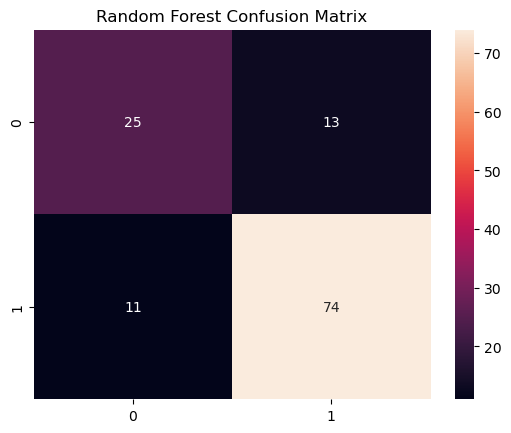

In [35]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.show()

## **ROC Curve**

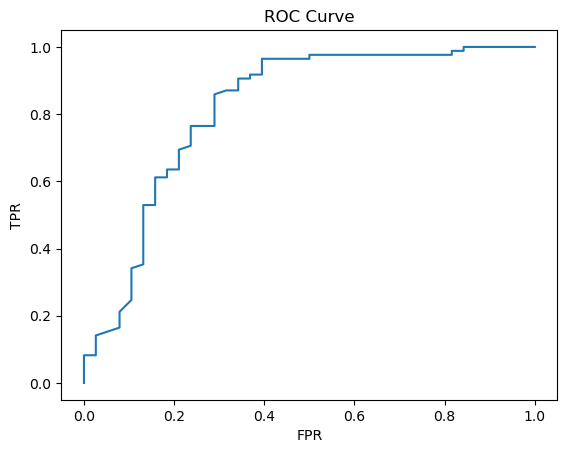

In [36]:
fpr,tpr,_ = roc_curve(
    y_test,
    rf_prob
)

plt.plot(
    fpr,
    tpr
)

plt.xlabel("FPR")
plt.ylabel("TPR")

plt.title("ROC Curve")

plt.show()

## **Feature Importance**

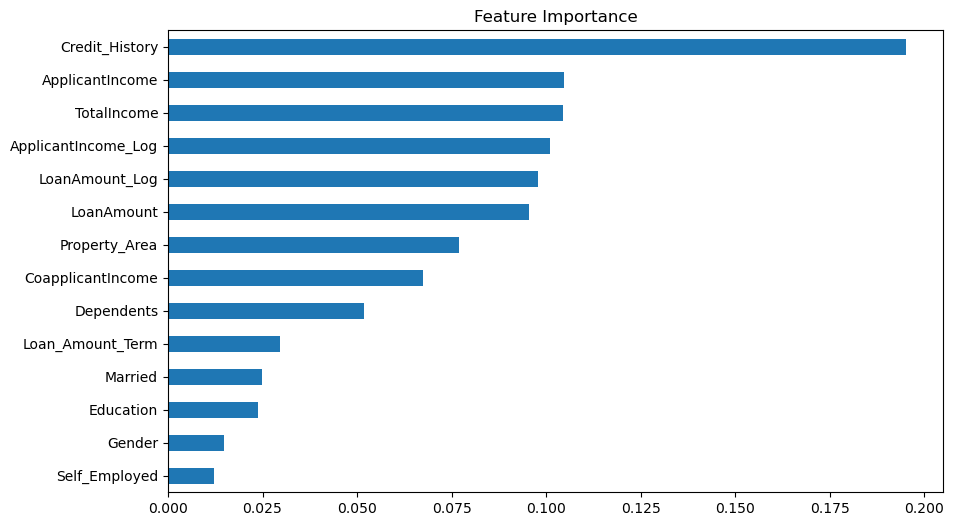

In [37]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title(
    "Feature Importance"
)

plt.show()

## **Threshold Optimization**

In [38]:
threshold = 0.40

rf_pred_new = (
    rf_prob >= threshold
).astype(int)

print(
    classification_report(
        y_test,
        rf_pred_new
    )
)

              precision    recall  f1-score   support

           0       0.85      0.61      0.71        38
           1       0.84      0.95      0.90        85

    accuracy                           0.85       123
   macro avg       0.85      0.78      0.80       123
weighted avg       0.85      0.85      0.84       123

